# Multimodal Fashion & Context Retrieval

**Glance ML Internship Assignment — Final Submission**

## Overview
This notebook implements an end-to-end pipeline that retrieves fashion images given a
free-text query describing **garment type, color, and environment/context** (e.g. *"A person
in a bright yellow raincoat"*, *"Professional business attire inside a modern office"*).

**Pipeline stages**

1. Load the Fashionpedia dataset and build a local image subset
2. Extract clothing category labels from dataset annotations
3. Augment weakly-represented environment buckets with additional images
4. Tag each image's environment/scene using a pretrained Places365 model
5. Extract each garment's dominant color via k-means clustering
6. Generate FashionCLIP embeddings and build a FAISS similarity index
7. Parse free-text queries into structured attributes (garment / color / environment)
8. Retrieve results via embedding similarity + attribute-aware re-ranking
9. Evaluate on the assignment's 5 test queries
10. Export the index and metadata for the retrieval repo

> **Runtime:** GPU recommended (Runtime → Change runtime type → T4 GPU).
> Run all cells top to bottom.


## Step 1 — Install Dependencies

In [3]:
!pip install -q datasets faiss-cpu transformers pillow scikit-learn matplotlib torch torchvision requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 59.0 MB/s eta 0:00:00


## Step 2 — Imports & Configuration

In [4]:
import os
import json
import getpass
import urllib.request
from collections import Counter

import numpy as np
import torch
import torch.nn.functional as F
import faiss
import requests
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

DATA_DIR = "/content/fashion_data"
IMAGES_DIR = f"{DATA_DIR}/images"
os.makedirs(IMAGES_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## Step 3 — Load Fashionpedia Dataset

We load the `detection-datasets/fashionpedia` split and materialize a local subset of
images (`SUBSET_SIZE`) to disk, since downstream steps (color extraction, embeddings) need
direct file access.


In [5]:
from datasets import load_dataset

dataset = load_dataset("detection-datasets/fashionpedia", split="train")
print("Total images available:", len(dataset))

SUBSET_SIZE = 700
subset = dataset.select(range(SUBSET_SIZE))

for i, item in enumerate(subset):
    img = item["image"].convert("RGB")
    img.save(f"{IMAGES_DIR}/{i:04d}.jpg")
    if i % 100 == 0:
        print(f"Saved {i}/{SUBSET_SIZE}")

print("Done saving images.")


Total images available: 45623
Saved 0/700
Saved 100/700
Saved 200/700
Saved 300/700
Saved 400/700
Saved 500/700
Saved 600/700
Done saving images.


## Step 4 — Extract Clothing Category Labels

`dataset.features['objects']['category']` is a `Sequence(ClassLabel)`, so the class names
live one level deeper at `.feature.names` (indexing the feature object directly raises
`'List' object is not subscriptable`).


In [6]:
category_names = dataset.features["objects"]["category"].feature.names
print("Total categories:", len(category_names))
print("Sample categories:", category_names[:10])

metadata = []
for i, item in enumerate(subset):
    objects = item["objects"]
    cat_ids = objects["category"]
    bboxes = objects["bbox"]  # [x, y, width, height] per object

    categories_in_image = [category_names[int(c)] for c in cat_ids]

    metadata.append({
        "image_id": f"{i:04d}",
        "file_path": f"{IMAGES_DIR}/{i:04d}.jpg",
        "clothing_categories": list(set(categories_in_image)),
        "per_object_categories": categories_in_image,
        "per_object_bboxes": bboxes,
        "width": item["width"],
        "height": item["height"],
        "source": "fashionpedia",
    })

print(f"Metadata built for {len(metadata)} images")
print("Sample entry:", metadata[0])


Total categories: 46
Sample categories: ['shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan', 'jacket', 'vest', 'pants', 'shorts', 'skirt', 'coat']
Metadata built for 700 images
Sample entry: {'image_id': '0000', 'file_path': '/content/fashion_data/images/0000.jpg', 'clothing_categories': ['shoe', 'dress', 'neckline'], 'per_object_categories': ['shoe', 'shoe', 'neckline', 'dress'], 'per_object_bboxes': [[445.0, 910.0, 505.0, 983.0], [239.0, 940.0, 284.0, 994.0], [298.0, 282.0, 386.0, 352.0], [210.0, 282.0, 448.0, 665.0]], 'width': 682, 'height': 1024, 'source': 'fashionpedia'}


## Step 5 — Augment Weak Environment Buckets (Unsplash)

Fashionpedia is a detection dataset, so its images skew toward studio/runway shots and are
sparse for everyday environments like *office*, *home*, *park*, and *street*. We top these
buckets up with real-world photos from the Unsplash API **before** running environment
tagging, color extraction, and embeddings, so every downstream step (including the
evaluation queries) sees the full combined dataset.

You'll need a free Unsplash API access key (2-minute signup at
[unsplash.com/developers](https://unsplash.com/developers)). It's requested at runtime
below rather than hardcoded, so this notebook is safe to share or commit without leaking
credentials.


In [7]:
UNSPLASH_ACCESS_KEY = os.environ.get("UNSPLASH_ACCESS_KEY") or getpass.getpass(
    "Unsplash API access key: "
)

SEARCH_QUERIES = {
    "office": ["business office outfit", "professional workwear office"],
    "home": ["home casual outfit", "loungewear at home"],
    "park": ["park outfit walking", "casual park style"],
    "street": ["street style outfit", "city walk fashion"],
}
IMAGES_PER_QUERY = 35


def fetch_unsplash_images(query, count=IMAGES_PER_QUERY):
    url = "https://api.unsplash.com/search/photos"
    params = {"query": query, "per_page": count, "client_id": UNSPLASH_ACCESS_KEY}
    resp = requests.get(url, params=params).json()
    return [r["urls"]["regular"] for r in resp.get("results", [])]


extra_images = {}
for bucket, queries in SEARCH_QUERIES.items():
    urls = []
    for q in queries:
        urls.extend(fetch_unsplash_images(q))
    extra_images[bucket] = urls
    print(f"{bucket}: {len(urls)} URLs fetched")


Unsplash API access key: ··········
office: 11 URLs fetched
home: 20 URLs fetched
park: 20 URLs fetched
street: 20 URLs fetched


In [8]:
extra_metadata = []
next_idx = len(metadata)

for bucket, urls in extra_images.items():
    for url in urls:
        try:
            img_path = f"{IMAGES_DIR}/{next_idx:04d}.jpg"
            urllib.request.urlretrieve(url, img_path)
            extra_metadata.append({
                "image_id": f"{next_idx:04d}",
                "file_path": img_path,
                "clothing_categories": [],       # no bbox annotations available for these
                "per_object_categories": [],
                "per_object_bboxes": [],
                "environment": bucket,            # known directly from the search query
                "raw_scene": f"unsplash_{bucket}",
                "source": "unsplash",
            })
            next_idx += 1
        except Exception as e:
            print("skip:", url, e)

metadata.extend(extra_metadata)
print(f"Added {len(extra_metadata)} images across weak buckets")
print(f"Total dataset size: {len(metadata)} images")


Added 71 images across weak buckets
Total dataset size: 771 images


## Step 6 — Environment Tagging with Places365

We tag each **Fashionpedia** image's scene using a pretrained Places365 ResNet-18, then map
its raw scene label into one of four target environment buckets (`office`, `street`, `park`,
`home`). Unsplash images already carry a known environment label from Step 5 and are skipped
here.


In [9]:
import torchvision.models as models
import torchvision.transforms as transforms

# Download pretrained Places365 ResNet-18 (weights + category list)
if not os.path.exists("resnet18_places365.pth.tar"):
    urllib.request.urlretrieve(
        "http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar",
        "resnet18_places365.pth.tar")

if not os.path.exists("categories_places365.txt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/csailvision/places365/master/categories_places365.txt",
        "categories_places365.txt")

places_classes = []
with open("categories_places365.txt") as f:
    for line in f:
        places_classes.append(line.strip().split(" ")[0][3:])

places_model = models.resnet18(num_classes=365)
checkpoint = torch.load("resnet18_places365.pth.tar", map_location="cpu")
state_dict = {k.replace("module.", ""): v for k, v in checkpoint["state_dict"].items()}
places_model.load_state_dict(state_dict)
places_model.eval().to(DEVICE)

places_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Bucket mapping: Places365 keyword -> our 4 target environments
BUCKET_KEYWORDS = {
    "office": ["office", "conference_room", "computer_room", "coworking_space", "reception"],
    "street": ["street", "crosswalk", "downtown", "alley", "plaza", "sidewalk", "city"],
    "park": ["park", "garden", "botanical_garden", "forest", "yard", "courtyard", "field"],
    "home": ["bedroom", "living_room", "home_office", "kitchen", "dining_room", "closet", "hallway"],
}


def bucket_for_scene(scene_name):
    for bucket, keywords in BUCKET_KEYWORDS.items():
        if any(kw in scene_name for kw in keywords):
            return bucket
    return "other"


def predict_environment(image_path):
    img = Image.open(image_path).convert("RGB")
    x = places_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = places_model(x)
        probs = F.softmax(logits, dim=1)
        top_idx = int(torch.argmax(probs, dim=1)[0])
    scene_name = places_classes[top_idx]
    return bucket_for_scene(scene_name), scene_name


print("Places365 model ready.")


Places365 model ready.


In [10]:
for i, entry in enumerate(metadata):
    if entry["source"] != "fashionpedia":
        continue  # Unsplash entries already have a known environment label
    bucket, raw_scene = predict_environment(entry["file_path"])
    entry["environment"] = bucket
    entry["raw_scene"] = raw_scene
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} tagged — last: {raw_scene} -> {bucket}")

print("Environment tagging done.")
print("Bucket distribution:", Counter(m["environment"] for m in metadata))


0/771 tagged — last: rope_bridge -> other
100/771 tagged — last: ballroom -> other
200/771 tagged — last: driveway -> other
300/771 tagged — last: stage/indoor -> other
400/771 tagged — last: bowling_alley -> street
500/771 tagged — last: promenade -> other
600/771 tagged — last: arena/performance -> other
Environment tagging done.
Bucket distribution: Counter({'other': 585, 'street': 80, 'park': 69, 'home': 24, 'office': 13})


## Step 7 — Dominant Color Extraction per Garment

Fashionpedia's category labels tell us *what* garment it is, but not *what color*. For each
garment bounding box we crop the region and use k-means to find its dominant color, then
snap that to the nearest named color (red, blue, yellow, white, black, etc.). Unsplash
images have no bounding boxes, so we approximate with a center-crop of the whole photo.


In [12]:
NAMED_COLORS = {
    "red": (220, 20, 60), "blue": (30, 60, 200), "yellow": (230, 200, 30),
    "green": (40, 140, 60), "black": (20, 20, 20), "white": (240, 240, 240),
    "gray": (130, 130, 130), "brown": (110, 70, 40), "pink": (230, 130, 180),
    "orange": (230, 120, 30), "purple": (120, 50, 150), "beige": (210, 190, 155),
}


def nearest_color_name(rgb):
    best_name, best_dist = None, float("inf")
    for name, ref in NAMED_COLORS.items():
        dist = sum((a - b) ** 2 for a, b in zip(rgb, ref))
        if dist < best_dist:
            best_dist, best_name = dist, name
    return best_name


def dominant_color_for_bbox(image, bbox):
    x, y, w, h = [int(v) for v in bbox]
    x, y = max(0, x), max(0, y)
    crop = image.crop((x, y, x + max(w, 1), y + max(h, 1))).convert("RGB")
    crop = crop.resize((32, 32))
    pixels = np.array(crop).reshape(-1, 3)
    if len(pixels) < 5:
        return "unknown"
    k = KMeans(n_clusters=1, n_init=3, random_state=0).fit(pixels)
    return nearest_color_name(k.cluster_centers_[0])


for i, entry in enumerate(metadata):
    img = Image.open(entry["file_path"]).convert("RGB")

    if entry["source"] == "fashionpedia":
        colors = [
            {"category": cat, "color": dominant_color_for_bbox(img, bbox)}
            for cat, bbox in zip(entry["per_object_categories"], entry["per_object_bboxes"])
        ]
    else:
        # No bbox annotations: approximate with a center-crop of the subject
        w, h = img.size
        center_bbox = (w * 0.25, h * 0.15, w * 0.5, h * 0.7)
        colors = [{"category": "unknown", "color": dominant_color_for_bbox(img, center_bbox)}]

    entry["garment_colors"] = colors
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} colors extracted")

print("Color extraction done.")
print("Sample:", metadata[0]["garment_colors"])


0/771 colors extracted
100/771 colors extracted
200/771 colors extracted
300/771 colors extracted
400/771 colors extracted
500/771 colors extracted
600/771 colors extracted
700/771 colors extracted
Color extraction done.
Sample: [{'category': 'shoe', 'color': 'black'}, {'category': 'shoe', 'color': 'black'}, {'category': 'neckline', 'color': 'gray'}, {'category': 'dress', 'color': 'gray'}]


## Step 8 — FashionCLIP Embeddings

We use `patrickjohncyh/fashion-clip`, a CLIP model fine-tuned on fashion data, which already
understands garments and styles better than vanilla CLIP.

For each image we also build a natural-language **pseudo-caption** from its structured
metadata (garment + color + environment) purely for documentation/debugging — the embedding
itself is computed from the image, and compositional accuracy comes from combining it with
the attribute re-ranker in Step 11.


In [13]:
from transformers import CLIPModel, CLIPProcessor

MODEL_NAME = "patrickjohncyh/fashion-clip"
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model.eval()


def embed_image(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        feats = clip_model.get_image_features(**inputs)
    if hasattr(feats, "pooler_output"):
        feats = feats.pooler_output
    feats = F.normalize(feats, dim=-1)
    return feats.cpu().numpy()[0]


def embed_text(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        feats = clip_model.get_text_features(**inputs)
    if hasattr(feats, "pooler_output"):
        feats = feats.pooler_output
    feats = F.normalize(feats, dim=-1)
    return feats.cpu().numpy()[0]


def build_pseudo_caption(entry):
    garment_desc = ", ".join(
        sorted(set(f"{g['color']} {g['category']}" for g in entry["garment_colors"]))
    )
    return f"A person wearing {garment_desc} in a {entry['environment']} setting."


print("FashionCLIP loaded.")


config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

FashionCLIP loaded.


In [14]:
image_embeddings = []
for i, entry in enumerate(metadata):
    entry["pseudo_caption"] = build_pseudo_caption(entry)
    image_embeddings.append(embed_image(entry["file_path"]))
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} embedded — caption: {entry['pseudo_caption']}")

image_embeddings = np.array(image_embeddings).astype("float32")
print("Embeddings shape:", image_embeddings.shape)


0/771 embedded — caption: A person wearing black shoe, gray dress, gray neckline in a other setting.
100/771 embedded — caption: A person wearing black neckline, black shoe, brown skirt, brown top, t-shirt, sweatshirt in a other setting.
200/771 embedded — caption: A person wearing black shoe, brown neckline, brown pants, brown shirt, blouse, gray bag, wallet, gray zipper in a other setting.
300/771 embedded — caption: A person wearing black dress, black neckline, black top, t-shirt, sweatshirt, brown neckline in a other setting.
400/771 embedded — caption: A person wearing black shoe, brown belt, brown dress, brown neckline, brown pocket in a street setting.
500/771 embedded — caption: A person wearing black shoe, brown cape, brown collar, brown top, t-shirt, sweatshirt, gray collar in a other setting.
600/771 embedded — caption: A person wearing black collar, black shoe, brown shirt, blouse, brown skirt, gray belt, gray pocket in a other setting.
700/771 embedded — caption: A person 

## Step 9 — Build FAISS Index

We index the normalized FashionCLIP image embeddings with a flat inner-product index
(equivalent to cosine similarity, since the vectors are already L2-normalized).


In [15]:
embedding_dim = image_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(image_embeddings)

print(f"FAISS index built: {faiss_index.ntotal} vectors, dimension {embedding_dim}")


FAISS index built: 771 vectors, dimension 512


## Step 10 — Query Parser (Rule-Based Attribute Extraction)

We pull out color / garment / environment keywords from the query text. This is used for
**re-ranking**, not for replacing the embedding search — embedding search finds the semantic
neighborhood, then attribute overlap boosts the images that actually match on the right
attribute *combination* (the compositionality fix).


In [16]:
GARMENT_KEYWORDS = set(category_names)
COLOR_KEYWORDS = set(NAMED_COLORS.keys())
ENV_KEYWORDS = {
    "office": "office", "park": "park", "street": "street", "city": "street",
    "home": "home", "house": "home", "indoor": "office", "outdoor": "park",
}

# Query word -> actual Fashionpedia category / color word
GARMENT_SYNONYMS = {
    "raincoat": "coat", "rain jacket": "jacket", "blazer": "jacket",
    "trousers": "pants", "jeans": "pants", "gown": "dress",
    "tee": "shirt", "tshirt": "shirt", "t-shirt": "shirt", "top": "shirt",
    "hoodie": "sweater", "sweatshirt": "sweater", "pullover": "sweater",
    "sneakers": "shoe", "trainers": "shoe", "footwear": "shoe",
}

COLOR_SYNONYMS = {
    "lemon": "yellow", "mustard": "yellow", "navy": "blue", "sky blue": "blue",
    "cream": "white", "ivory": "white", "maroon": "red", "crimson": "red",
    "olive": "green", "mint": "green", "charcoal": "black", "tan": "brown",
}

# Style -> implied garments, for queries like "casual weekend outfit" / "formal setting"
STYLE_GARMENT_MAP = {
    "casual": ["sweater", "shoe", "pants", "shirt"],
    "formal": ["jacket", "tie", "dress", "shirt"],
    "business": ["jacket", "tie", "shirt", "pants"],
    "weekend": ["sweater", "shoe", "pants"],
}


def parse_query(query):
    q = query.lower()

    for synonym, real_name in {**GARMENT_SYNONYMS, **COLOR_SYNONYMS}.items():
        if synonym in q:
            q += f" {real_name}"

    found_colors = [c for c in COLOR_KEYWORDS if c in q]
    found_garments = [g for g in GARMENT_KEYWORDS if g in q]

    # If a style word (casual/formal/business/weekend) is present, soft-hint its
    # associated garments too
    style_garments = []
    for style_word, implied_garments in STYLE_GARMENT_MAP.items():
        if style_word in q:
            style_garments.extend(implied_garments)

    found_env = None
    for kw, bucket in ENV_KEYWORDS.items():
        if kw in q:
            found_env = bucket
            break

    return {
        "colors": found_colors,
        "garments": found_garments,
        "style_garments": list(set(style_garments)),
        "environment": found_env,
    }


# Sanity check
print(parse_query("A person in a lemon hoodie"))
print(parse_query("Casual weekend outfit for a city walk"))


{'colors': ['yellow'], 'garments': ['hood', 'sweater'], 'style_garments': [], 'environment': None}
{'colors': [], 'garments': [], 'style_garments': ['pants', 'shoe', 'sweater', 'shirt'], 'environment': 'street'}


## Step 11 — Retriever: Embedding Search + Attribute Re-Ranking

Real-life analogy: embedding search is like asking a friend "which of these looks like the
same vibe?" — fast but a little fuzzy. Attribute re-ranking is like then checking each
candidate against your actual checklist (color match? garment match? location match?)
before finalizing the shortlist.


In [17]:
def compute_attribute_score(entry, parsed):
    """Weighted match score: garment > color > environment."""
    entry_colors = {g["color"] for g in entry["garment_colors"]}
    entry_garments = {g["category"] for g in entry["garment_colors"]}

    # Hard garments (explicit match) + soft garments (style-inferred, half weight)
    garment_hit = bool(entry_garments & set(parsed["garments"])) if parsed["garments"] else None
    style_hit = bool(entry_garments & set(parsed["style_garments"])) if parsed["style_garments"] else None
    color_hit = bool(entry_colors & set(parsed["colors"])) if parsed["colors"] else None
    env_hit = (entry["environment"] == parsed["environment"]) if parsed["environment"] else None

    garment_score = 1.0 if garment_hit else (0.5 if style_hit else (0.0 if (parsed["garments"] or parsed["style_garments"]) else 1.0))
    color_score = 1.0 if color_hit else (0.0 if parsed["colors"] else 1.0)
    env_score = 1.0 if env_hit else (0.0 if parsed["environment"] else 1.0)

    # Weights: garment matters most, then color, then environment
    return 0.5 * garment_score + 0.3 * color_score + 0.2 * env_score


def retrieve(query, top_k=5):
    parsed = parse_query(query)
    print("Parsed attributes:", parsed)

    query_emb = embed_text(query).reshape(1, -1).astype("float32")
    embedding_sims = (image_embeddings @ query_emb.T).flatten()

    scored = []
    for i, entry in enumerate(metadata):
        attr_score = compute_attribute_score(entry, parsed)
        # Fused score: semantic similarity + precise attribute match
        final_score = 0.6 * embedding_sims[i] + 0.4 * attr_score
        scored.append((final_score, embedding_sims[i], attr_score, i))

    scored.sort(reverse=True, key=lambda x: x[0])

    results = []
    for final_score, emb_sim, attr_score, idx in scored[:top_k]:
        results.append({
            "entry": metadata[idx],
            "final_score": float(final_score),
            "embedding_similarity": float(emb_sim),
            "attribute_score": float(attr_score),
        })
    return results


## Step 12 — Result Visualization

In [18]:
def show_results(query, results):
    print(f"\n{'=' * 70}\nQuery: {query}\n{'=' * 70}")
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
    if len(results) == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["entry"]["file_path"]).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"final: {r['final_score']:.2f}\n"
            f"emb: {r['embedding_similarity']:.2f} | attr: {r['attribute_score']:.2f}\n"
            f"{r['entry']['environment']}",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()


## Step 13 — Run the 5 Assignment Evaluation Queries

Parsed attributes: {'colors': ['yellow'], 'garments': ['coat'], 'style_garments': [], 'environment': None}

Query: A person in a bright yellow raincoat.


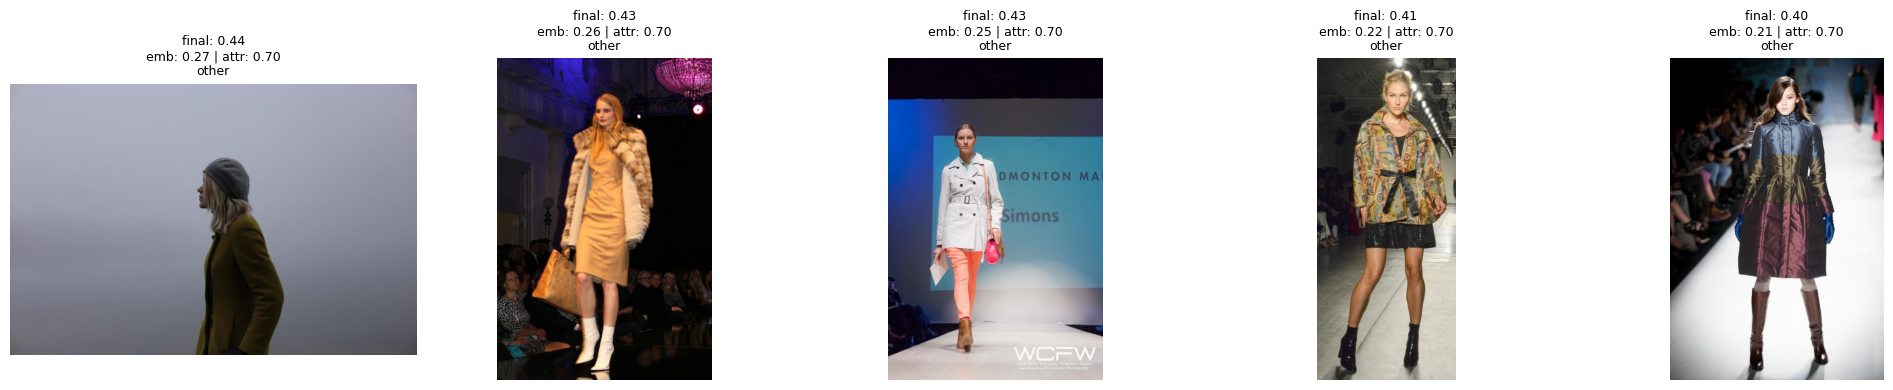

Parsed attributes: {'colors': [], 'garments': [], 'style_garments': ['pants', 'shirt', 'jacket', 'tie'], 'environment': 'office'}

Query: Professional business attire inside a modern office.


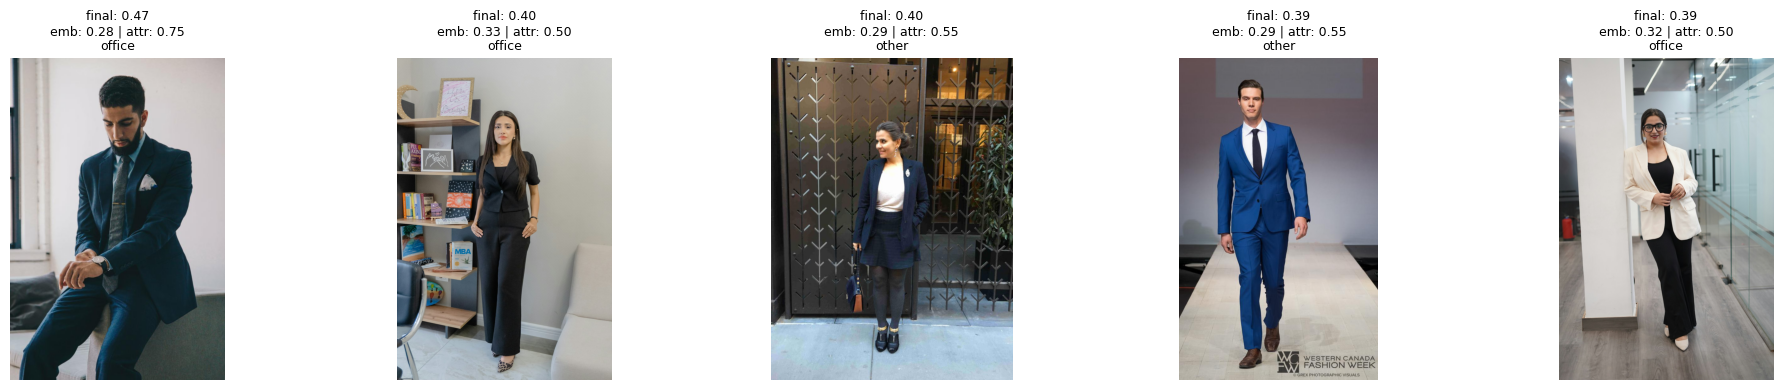

Parsed attributes: {'colors': ['blue'], 'garments': [], 'style_garments': [], 'environment': 'park'}

Query: Someone wearing a blue shirt sitting on a park bench.


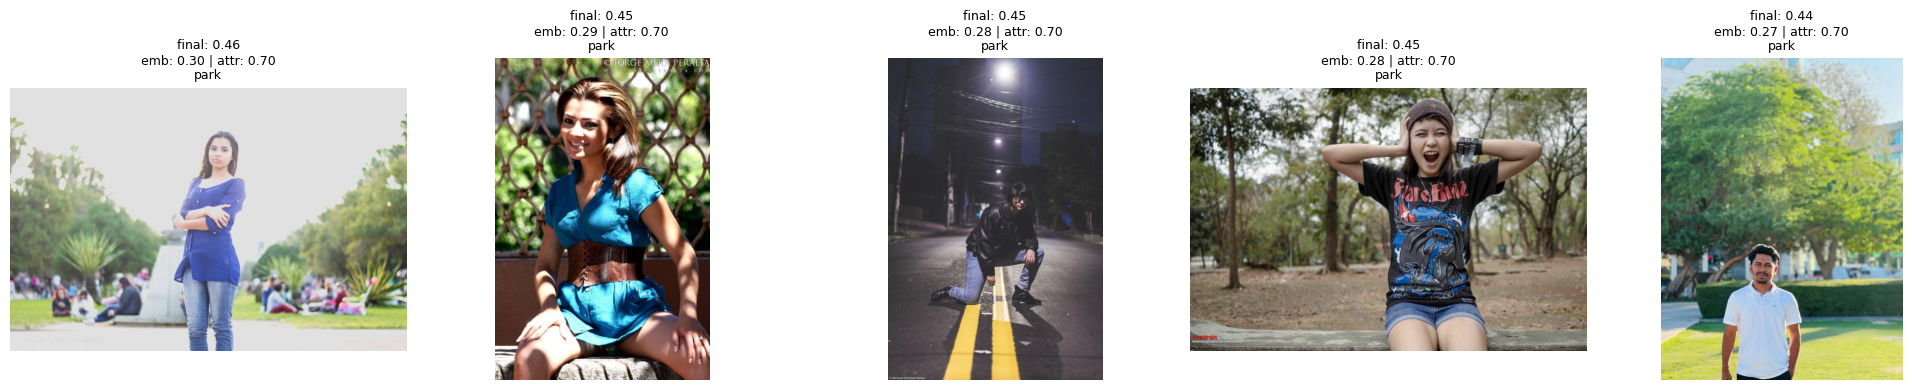

Parsed attributes: {'colors': [], 'garments': [], 'style_garments': ['pants', 'shoe', 'sweater', 'shirt'], 'environment': 'street'}

Query: Casual weekend outfit for a city walk.


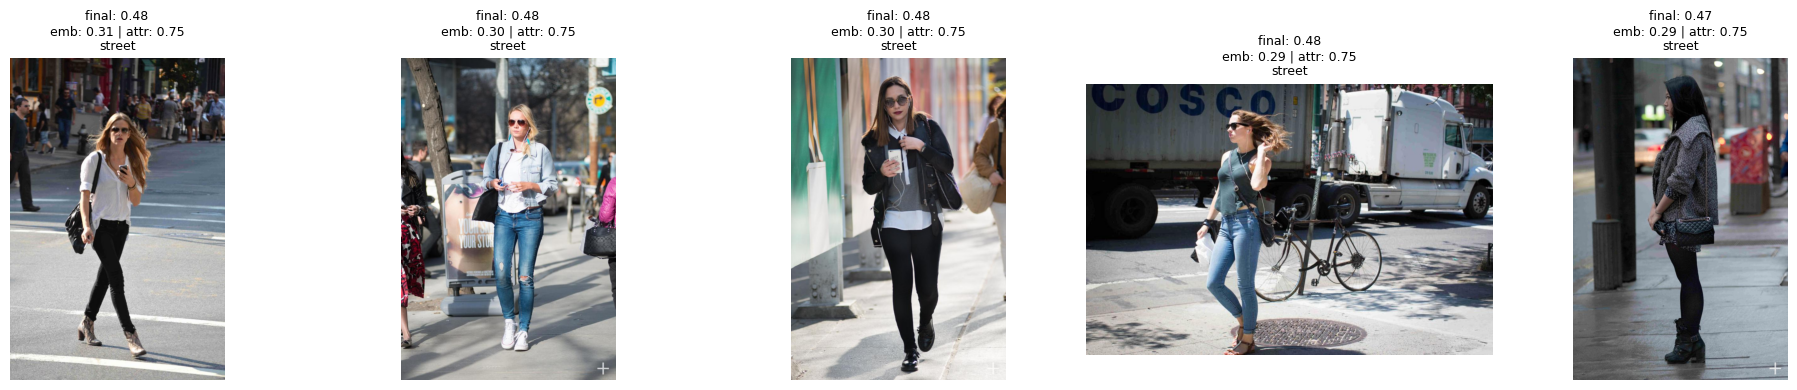

Parsed attributes: {'colors': ['white', 'red'], 'garments': ['tie'], 'style_garments': ['shirt', 'jacket', 'tie', 'dress'], 'environment': None}

Query: A red tie and a white shirt in a formal setting.


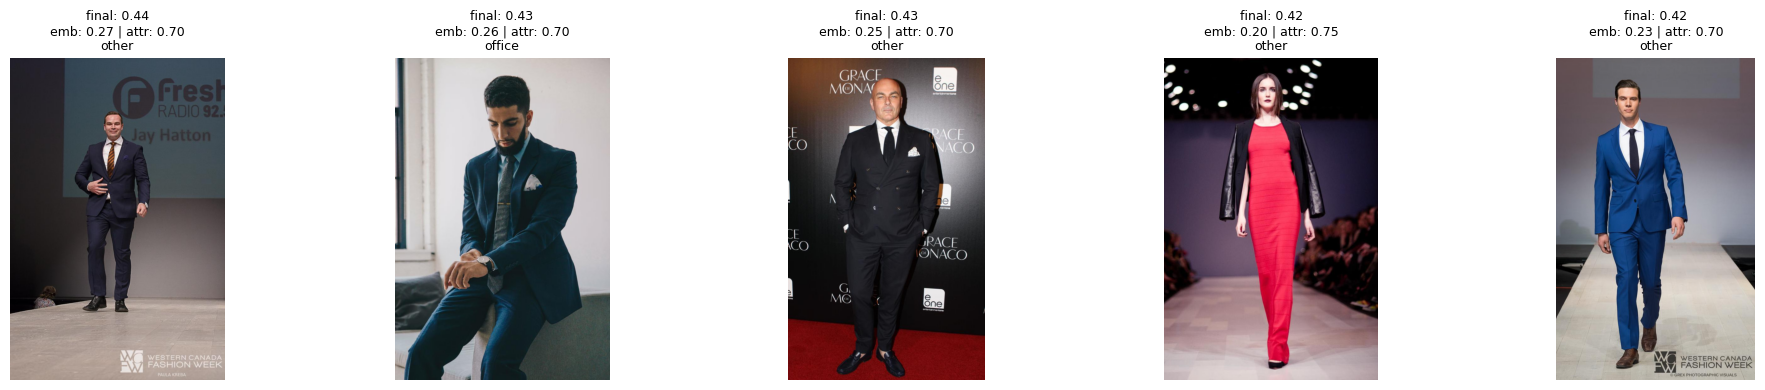

In [19]:
EVAL_QUERIES = [
    "A person in a bright yellow raincoat.",
    "Professional business attire inside a modern office.",
    "Someone wearing a blue shirt sitting on a park bench.",
    "Casual weekend outfit for a city walk.",
    "A red tie and a white shirt in a formal setting.",
]

for q in EVAL_QUERIES:
    results = retrieve(q, top_k=5)
    show_results(q, results)


## Step 14 — Save Artifacts for the Repository

We persist the FAISS index and metadata to disk. Copy both files into your repo's
`indexer/` output (or a `data/` folder) — your `retrieve.py` script should load them
alongside the FashionCLIP model and reuse the `retrieve()` function defined above.


In [ ]:
FAISS_INDEX_PATH = f"{DATA_DIR}/fashion_index.faiss"
METADATA_PATH = f"{DATA_DIR}/metadata.json"

faiss.write_index(faiss_index, FAISS_INDEX_PATH)

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f)

print("Files saved:")
print(" -", FAISS_INDEX_PATH)
print(" -", METADATA_PATH)
print("Download these via the Colab file browser (left sidebar) before your session ends.")


## Summary

- **Dataset:** Fashionpedia subset (700 images) augmented with Unsplash images for
  under-represented environments (office / home / park / street).
- **Environment tagging:** Places365 ResNet-18, mapped to 4 target buckets.
- **Color extraction:** k-means dominant color per garment bounding box.
- **Embeddings:** FashionCLIP (`patrickjohncyh/fashion-clip`), indexed with FAISS
  (`IndexFlatIP` / cosine similarity).
- **Retrieval:** embedding similarity fused with a rule-based attribute re-ranker
  (garment > color > environment) to handle compositional queries.
- **Output:** `fashion_index.faiss` + `metadata.json`, consumed by `retrieve.py` in the
  submission repository.


In [21]:
# Step 15 — Gradio Search UI
!pip install -q gradio

import gradio as gr


def search_ui(query, top_k):
    if not query.strip():
        return [], "Enter a query above."

    results = retrieve(query, top_k=int(top_k))

    gallery_items = []
    for r in results:
        img = Image.open(r["entry"]["file_path"]).convert("RGB")
        caption = (
            f"final: {r['final_score']:.2f} | "
            f"emb: {r['embedding_similarity']:.2f} | "
            f"attr: {r['attribute_score']:.2f} | "
            f"env: {r['entry']['environment']}"
        )
        gallery_items.append((img, caption))

    parsed = parse_query(query)
    parsed_str = (
        f"Garments: {parsed['garments'] or '—'} | "
        f"Colors: {parsed['colors'] or '—'} | "
        f"Environment: {parsed['environment'] or '—'}"
    )
    return gallery_items, parsed_str


EXAMPLE_QUERIES = [
    "A person in a bright yellow raincoat.",
    "Professional business attire inside a modern office.",
    "Someone wearing a blue shirt sitting on a park bench.",
    "Casual weekend outfit for a city walk.",
    "A red tie and a white shirt in a formal setting.",
]

with gr.Blocks(title="Fashion & Context Retrieval") as demo:
    gr.Markdown("# Multimodal Fashion & Context Retrieval\nSearch by garment, color, and environment.")

    with gr.Row():
        query_box = gr.Textbox(
            label="Search query",
            placeholder="e.g. A person in a bright yellow raincoat.",
            scale=4,
        )
        top_k_slider = gr.Slider(1, 10, value=5, step=1, label="Results", scale=1)

    search_btn = gr.Button("Search", variant="primary")
    parsed_display = gr.Textbox(label="Parsed attributes", interactive=False)
    gallery = gr.Gallery(label="Results", columns=5, height="auto")

    gr.Examples(examples=EXAMPLE_QUERIES, inputs=query_box)

    search_btn.click(fn=search_ui, inputs=[query_box, top_k_slider], outputs=[gallery, parsed_display])
    query_box.submit(fn=search_ui, inputs=[query_box, top_k_slider], outputs=[gallery, parsed_display])

demo.launch(share=True, debug=True)

ERROR: Operation cancelled by user
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().


KeyboardInterrupt: 